# Random Forest Model for Water Potability

This notebook will contain the pipeline for building, training, and evaluating a Random Forest model to predict water potability.

## 1. Setup and Exploratory Data Analysis (EDA)
First, let's load the necessary libraries and the dataset, and perform some basic EDA.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [4]:
# Load the dataset
df = pd.read_csv('water_potability.csv')
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [5]:
# Check dataset information and missing values
print("Dataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB

Missing Values:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


C:\Users\chand\AppData\Local\Temp\ipykernel_20008\382900907.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Potability', palette='Set2')


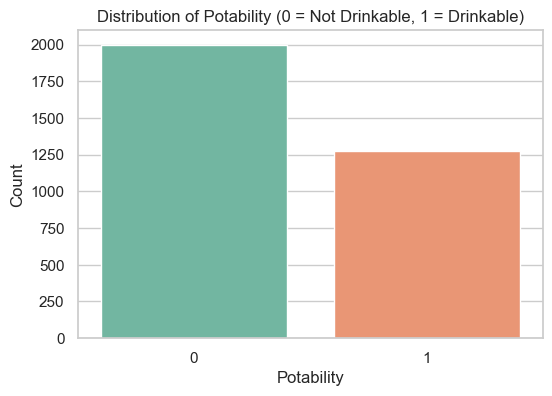

In [6]:
# Visualize the distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Potability', palette='Set2')
plt.title('Distribution of Potability (0 = Not Drinkable, 1 = Drinkable)')
plt.xlabel('Potability')
plt.ylabel('Count')
plt.show()

## 2. Data Preprocessing
We replicate the exact preprocessing steps established by the group (mean imputation followed by standard scaling) to ensure fair comparison and avoid merge conflicts.

In [7]:
from sklearn.impute import SimpleImputer

# 1. Mean imputation for null values
imputer = SimpleImputer(strategy='mean')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# 2. Separate feature and target variables
X = df_imputed.drop("Potability", axis=1)
y = df_imputed["Potability"]

# Check imputation
print("Remaining missing values:", df_imputed.isnull().sum().sum())

Remaining missing values: 0


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 3. Data splitting for training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 4. Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Set Shape:", X_train_scaled.shape)
print("Testing Set Shape:", X_test_scaled.shape)

Training Set Shape: (2620, 9)
Testing Set Shape: (656, 9)


## 3. Baseline Random Forest Model
Let's start by training a baseline Random Forest Classifier with default parameters to see how it performs out of the box based on the preprocessed data.



In [9]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the model with a random state for reproducibility
rf_baseline = RandomForestClassifier(random_state=42)

# Train the model on the scaled training data
rf_baseline.fit(X_train_scaled, y_train)

print("Baseline Random Forest model trained successfully!")


Baseline Random Forest model trained successfully!


In [10]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions on the test set
y_pred_baseline = rf_baseline.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_baseline)
print(f"Baseline Accuracy: {accuracy:.4f}\n")

# Generate the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_baseline))


Baseline Accuracy: 0.6555

Classification Report:
              precision    recall  f1-score   support

         0.0       0.67      0.88      0.76       400
         1.0       0.62      0.31      0.41       256

    accuracy                           0.66       656
   macro avg       0.64      0.59      0.59       656
weighted avg       0.65      0.66      0.62       656



### 3.3 ROC Curve and AUC
Next, we'll plot the Receiver Operating Characteristic (ROC) curve and calculate the Area Under the Curve (AUC) to evaluate the model's ability to distinguish between drinkable and non-drinkable water at various thresholds.


In [ ]:
from sklearn.metrics import roc_curve, auc

# Get predicted probabilities for the positive class (Drinkable)
y_pred_prob_baseline = rf_baseline.predict_proba(X_test_scaled)[:, 1]

# Calculate False Positive Rate, True Positive Rate, and Thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_baseline)

# Calculate AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Baseline Model')
plt.legend(loc="lower right")
plt.show()
